In [25]:
'''
Import and load data set
'''

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

X_train=pd.read_csv("../output/x_train.csv")
X_test=pd.read_csv("../output/x_test.csv")
y_train=pd.read_csv("../output/y_train.csv").squeeze()
y_test=pd.read_csv("../output/y_test.csv").squeeze()


In [26]:
'''
Create the Decision Tree model, train, and predict
'''

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_predicted = decision_tree_model.predict(X_test)


In [27]:
'''
Predict accuracy and f1 scores
'''

accuracy_of_the_decision_tree_model = accuracy_score(y_test, y_predicted)

f1_of_the_decision_tree_model = f1_score(y_test, y_predicted, average="weighted")

# Recall and Precision scores
precision_of_the_decision_tree_model = precision_score(y_test,y_predicted,average="weighted", zero_division=0)

recall_of_the_decision_tree_model = recall_score(y_test,y_predicted,average="weighted", zero_division=0)

#ROC-AUC
y_pred_proba = decision_tree_model.predict_proba(X_test)

roc_auc_of_the_decision_tree_model = roc_auc_score(y_test,y_pred_proba,multi_class="ovr",average="weighted")


In [28]:
'''
Print model results
'''

print("Decision Tree Results")
print(f"Accuracy: {accuracy_of_the_decision_tree_model:.4f}")
print(f"F1-score: {f1_of_the_decision_tree_model:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall_of_the_decision_tree_model:.4f}")
print(f"ROC-AUC: {roc_auc_of_the_decision_tree_model:.4f}")


Decision Tree Results
Accuracy: 0.5551
F1-score: 0.5411
Precision: 0.5357
Recall: 0.5551
ROC-AUC: 0.7008


In [29]:
'''
Analyze most important features and print
'''

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)



Feature Importance:
                 Feature  Importance
10               alcohol    0.395808
9              sulphates    0.170585
1       volatile acidity    0.113246
6   total sulfur dioxide    0.100810
7                density    0.052291
0          fixed acidity    0.043783
8                     pH    0.039047
3         residual sugar    0.038161
5    free sulfur dioxide    0.018667
4              chlorides    0.014941
2            citric acid    0.012662


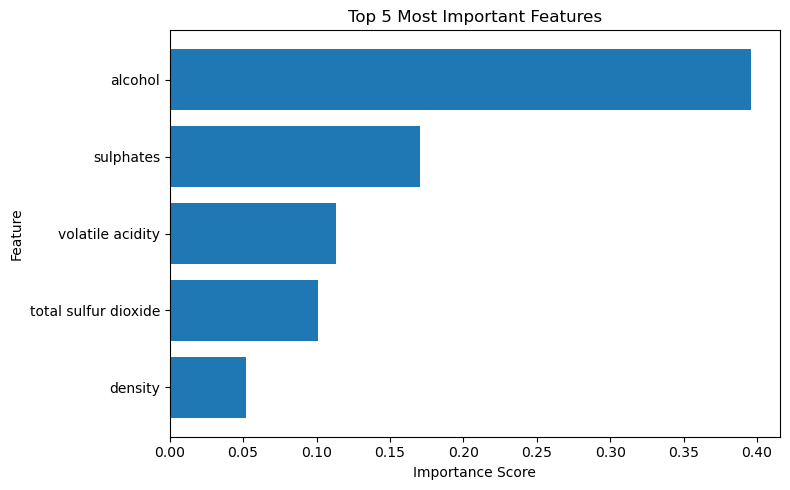

In [30]:
'''
Make graph of importance
'''

top_features = feature_importance.head(5)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 5 Most Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

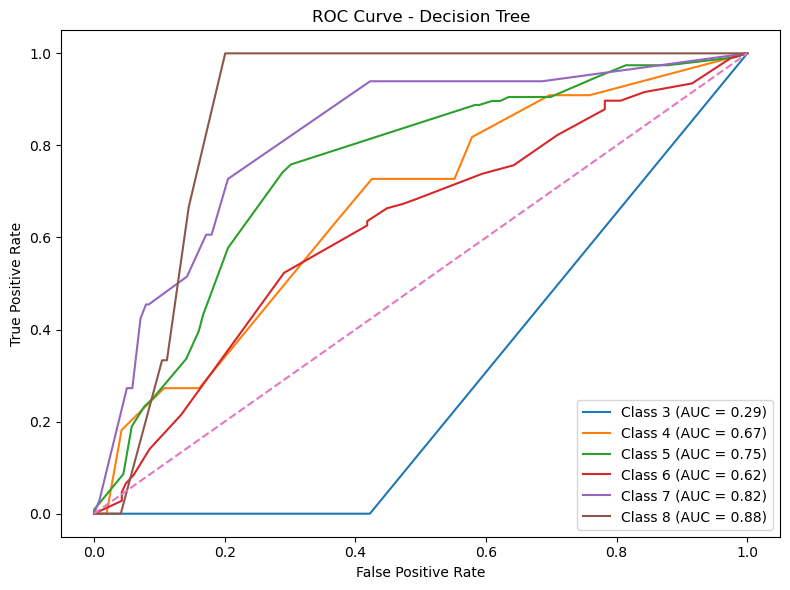

In [31]:
'''
ROC-AUC Graph
'''

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for current_element in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, current_element],
        y_pred_proba[:, current_element]
    )

    roc_auc_class = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[current_element]} (AUC = {roc_auc_class:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
'''
Make CSV for evaluation
'''

decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree Classifier"],
    "Accuracy": [accuracy_of_the_decision_tree_model],
    "Precision": [precision],
    "Recall": [recall_of_the_decision_tree_model],
    "F1-Score": [f1_of_the_decision_tree_model],
    "ROC-AUC": [roc_auc_of_the_decision_tree_model],
})

decision_tree_results.to_csv("../output/decision_tree_results.csv", index=False)